# Projeto Análise de Performance Logística

## 1. Objetivo e Contexto

A empresa tem recebido um aumento nas reclamações relacionadas à pontualidade das entregas. A área operacional indica que os prazos estão condizentes com a distância das rotas, mas destaca que os esforços para manter os níveis de serviço têm impactado diretamente o custo das operações, especialmente em rotas mais longas.

<br> Esta EDA tem como objetivo analisar a performance das entregas com foco em pontualidade e custo, a fim de:

- Confirmar se as reclamações dos clientes possuem fundamento
- Identificar as principais causas dos atrasos
- Avaliar o comportamentos dos custos com as entregas

## 2. Configuração de Ambiente

### 2.1 - Intalação e importação

In [ ]:
# Instalar bibliotecas
!pip install sqlalchemy psycopg2-binary python-dotenv

In [ ]:
# Importar bibliotecas
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus  # necessário para tratar caracteres especiais na senha
from google.colab import drive       # necessário para acessar o .env salvo no Google Drive
import os

# Bibliotecas para mensuração e Análise de dados
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

# Carregar o .env
# O .env foi salvo no Google Drive para garantir persistência entre sessões
# No Colab, o .env some quando a sessão reinicia — por isso usamos o Drive
drive.mount('/content/drive')
load_dotenv('/content/drive/MyDrive/.env', override=True)

# Guardar as variáveis
user     = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host     = os.getenv("DB_HOST")
port     = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

# Verificação: garante que o .env foi lido corretamente antes de prosseguir
print(password is None)  # False = variáveis carregadas com sucesso

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
False



### 2.2 - Carregamento dos dados  

In [ ]:
# Configuração da conexão com o banco
# quote_plus converte caracteres especiais (como # e !) para formato aceito na URL
password_encoded = quote_plus(password)
connection_string = f"postgresql://{user}:{password_encoded}@{host}:{port}/{database}?sslmode=require"

# Criação da engine SQLAlchemy
engine = create_engine(connection_string)

# Consulta dos dados tratados
query = "SELECT * FROM silver.entregas_clean"

# Carregamento dos dados para DataFrame
df = pd.read_sql(query, engine)

# Encerramento da conexão
# Importante: evita conexões abertas desnecessárias e problemas de limite no Neon
engine.dispose()

df.head()

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real
0,SH10000,Warehouse_MIA,San Francisco,UPS,DELIVERED,2023-10-02,2023-10-04,25.7,67.46,291.0,468.32,2,2.0
1,SH10001,Warehouse_MIA,Atlanta,DHL,DELIVERED,2023-12-06,2023-12-09,38.9,268.85,1225.0,1971.44,3,3.0
2,SH10002,Warehouse_LA,Houston,DHL,DELIVERED,2023-09-18,2023-09-20,37.2,74.35,220.0,354.05,2,2.0
3,SH10003,Warehouse_BOS,Seattle,ONTRAC,DELIVERED,2023-01-26,2023-02-04,42.6,187.04,1156.0,1860.40,9,9.0
4,SH10004,Warehouse_SF,Dallas,ONTRAC,DELIVERED,2023-06-03,2023-06-06,7.9,120.01,1017.0,1636.70,3,3.0


## 3. Visão Geral dos Dados

Objetivo:
Validar se a base foi carregada corretamente e compreender sua estrutura antes do início das análises.

###  3.1 - Quantidade de linhas e colunas

In [ ]:
df.shape

(1983, 13)

### 3.2 - Tipo de cada coluna

In [ ]:
print(df.dtypes)

id_envio                   object
armazem_origem             object
destino                    object
transportadora             object
status                     object
data_envio                 object
data_entrega               object
peso_kg                   float64
custo                     float64
distancia_milhas          float64
distancia_km              float64
dias_transito_original      int64
dias_transito_real        float64
dtype: object


### 3.3 - Informações Gerais

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1983 entries, 0 to 1982
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_envio                1983 non-null   object 
 1   armazem_origem          1983 non-null   object 
 2   destino                 1983 non-null   object 
 3   transportadora          1983 non-null   object 
 4   status                  1983 non-null   object 
 5   data_envio              1983 non-null   object 
 6   data_entrega            1952 non-null   object 
 7   peso_kg                 1983 non-null   float64
 8   custo                   1944 non-null   float64
 9   distancia_milhas        1983 non-null   float64
 10  distancia_km            1983 non-null   float64
 11  dias_transito_original  1983 non-null   int64  
 12  dias_transito_real      1952 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 201.5+ KB


In [ ]:
# Conversão de datas de envio e entrega para formato de data
df['data_envio'] = pd.to_datetime(df['data_envio'], errors='coerce')
df['data_entrega'] = pd.to_datetime(df['data_entrega'], errors='coerce')

print('Formato das datas após conversão:\n', df[['data_envio','data_entrega' ]].dtypes)

Formato das datas após conversão:
 data_envio      datetime64[ns]
data_entrega    datetime64[ns]
dtype: object


A base de dados contém 1983 linhas e 13 colunas, ou seja 1983 registros e 13 variáveis.  
Cada registro representa uma entrega realizada pela transportara.

As variáveis disponíveis contemplam informações operacionais relevantes para a análise logística, incluindo:
- Origem e destino das entregas;
- Transportadora responsável;
- Datas de envio e entrega;
- Peso transportado;
- Distância percorrida;
- Custo do envio;
- Tempo de trânsito.


## 4. Análises dos Dados

### 4.1 - Criar variável de atraso

 #### 4.1.1 -Criação da variável `p90_dias`


In [ ]:
df['rota'] = df['armazem_origem'] + " - " + df['destino'] # Cria variável rota

df['p90_dias'] = df.groupby(['rota'])['dias_transito_real'].transform(lambda x: np.percentile(x.dropna(), 90))

 #### 4.1.2 - Criação da variável `p10_km_por_dia`

In [ ]:
# Relação entre distância percorrida e dias reais de trânsito
# NaN quando dias_transito_real é nulo
df['km_por_dia'] = df['distancia_km'] / df['dias_transito_real']


df['p10_km_por_dia'] = df.groupby(['rota'])['km_por_dia'].transform(lambda x: np.percentile(x.dropna(), 10))

 #### 4.1.3 - Criação da variável `entregas_atrasadas`

In [ ]:
# Função de classificação por comportamento de rota
def classificar_por_rota(df):
    """
    Classifica cada entrega como 'True' ou 'False'.
    Retorna uma Series com os valores classificados.
    Uma entrega é considerada atrasada (True) quando ultrapassa os limites
    de desempenho definidos pelos percentis calculados para a própria rota.
    """

    classificacao = pd.Series(index=df.index, dtype='object')

    for idx, row in df.iterrows():
        dias   = row['dias_transito_real']
        km_dia = row['km_por_dia']
        p90    = row['p90_dias']
        p10    = row['p10_km_por_dia']

        # Sem dados suficientes para classificar
        if pd.isna(dias) or pd.isna(km_dia):
            classificacao.loc[idx] = None
            continue

        # Classifica de acordo com percentis calculados para a própria rota
        if dias > p90 or km_dia < p10:
            classificacao.loc[idx] = True
        else:
            classificacao.loc[idx] = False

    return classificacao

In [ ]:
# Criação da coluna entregas_atrasadas
df['entregas_atrasadas'] = classificar_por_rota(df)

print("Contagem da colunas entregas após aplicar função:\n", df['entregas_atrasadas'].value_counts(dropna=False))

# Classifica entregas com estatos 'LOST' (PERDIDO) como atrasado
df.loc[df['status'] == 'LOST', 'entregas_atrasadas'] = True

print("\nContagem da colunas entregas após classicar perdidos:\n", df['entregas_atrasadas'].value_counts(dropna=False))

print('\n',df.head().to_string())

Contagem da colunas entregas após aplicar função:
 entregas_atrasadas
False    1580
True      372
None       31
Name: count, dtype: int64

Contagem da colunas entregas após classicar pedidos:
 entregas_atrasadas
False    1545
True      407
None       31
Name: count, dtype: int64

   id_envio armazem_origem        destino transportadora     status data_envio data_entrega  peso_kg   custo  distancia_milhas  distancia_km  dias_transito_original  dias_transito_real                           rota  p90_dias  km_por_dia  p10_km_por_dia entregas_atrasadas
0  SH10000  Warehouse_MIA  San Francisco            UPS  DELIVERED 2023-10-02   2023-10-04     25.7   67.46             291.0        468.32                       2                 2.0  Warehouse_MIA - San Francisco       7.0  234.160000      311.140000               True
1  SH10001  Warehouse_MIA        Atlanta            DHL  DELIVERED 2023-12-06   2023-12-09     38.9  268.85            1225.0       1971.44                       3           

A base original possuía uma coluna de status indicando se a entrega estava atrasada ou não. No entanto, foi criada uma nova variável de atraso para tornar a análise mais aderente ao comportamento real dos dados.

Para isso, foi criada inicialmente a variável `rota`, combinando origem e destino. Em seguida, foram calculados dois indicadores para cada rota:
- p90_dias: percentil 90 dos dias de trânsito;
- p10_km_por_dia: percentil 10 da quilometragem percorrida por dia.
Esses percentis representam limites de desempenho observados no histórico de cada rota.

Uma entrega foi classificada como atrasada quando apresentou:
- tempo de trânsito acima do percentil 90 da rota; ou
- quilometragem por dia abaixo do percentil 10 da rota.

Além disso, entregas com status LOST(PERDIDO) foram classificadas como atrasadas por regra de negócio.

### 4.2 - Análise de estatísticas descritivas

Objetivo:
estabelecer uma visão geral da operação e compreender o comportamento padrão do dados

In [ ]:
# Estatísticas descritivas das variáveis principais
variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_real']

estatisticas = df[variaveis].agg(['mean', 'min', 'max']).T

# Adiciona percentil 90
estatisticas['percentil_90'] = df[variaveis].quantile(0.9)

print(estatisticas.round(2))

                       mean     min      max  percentil_90
custo                205.15   17.89  6562.21        324.85
peso_kg               30.22    0.00  5404.20         51.96
distancia_km        2052.78  162.54  4021.74       3621.02
dias_transito_real     4.90    1.00    20.00          8.00


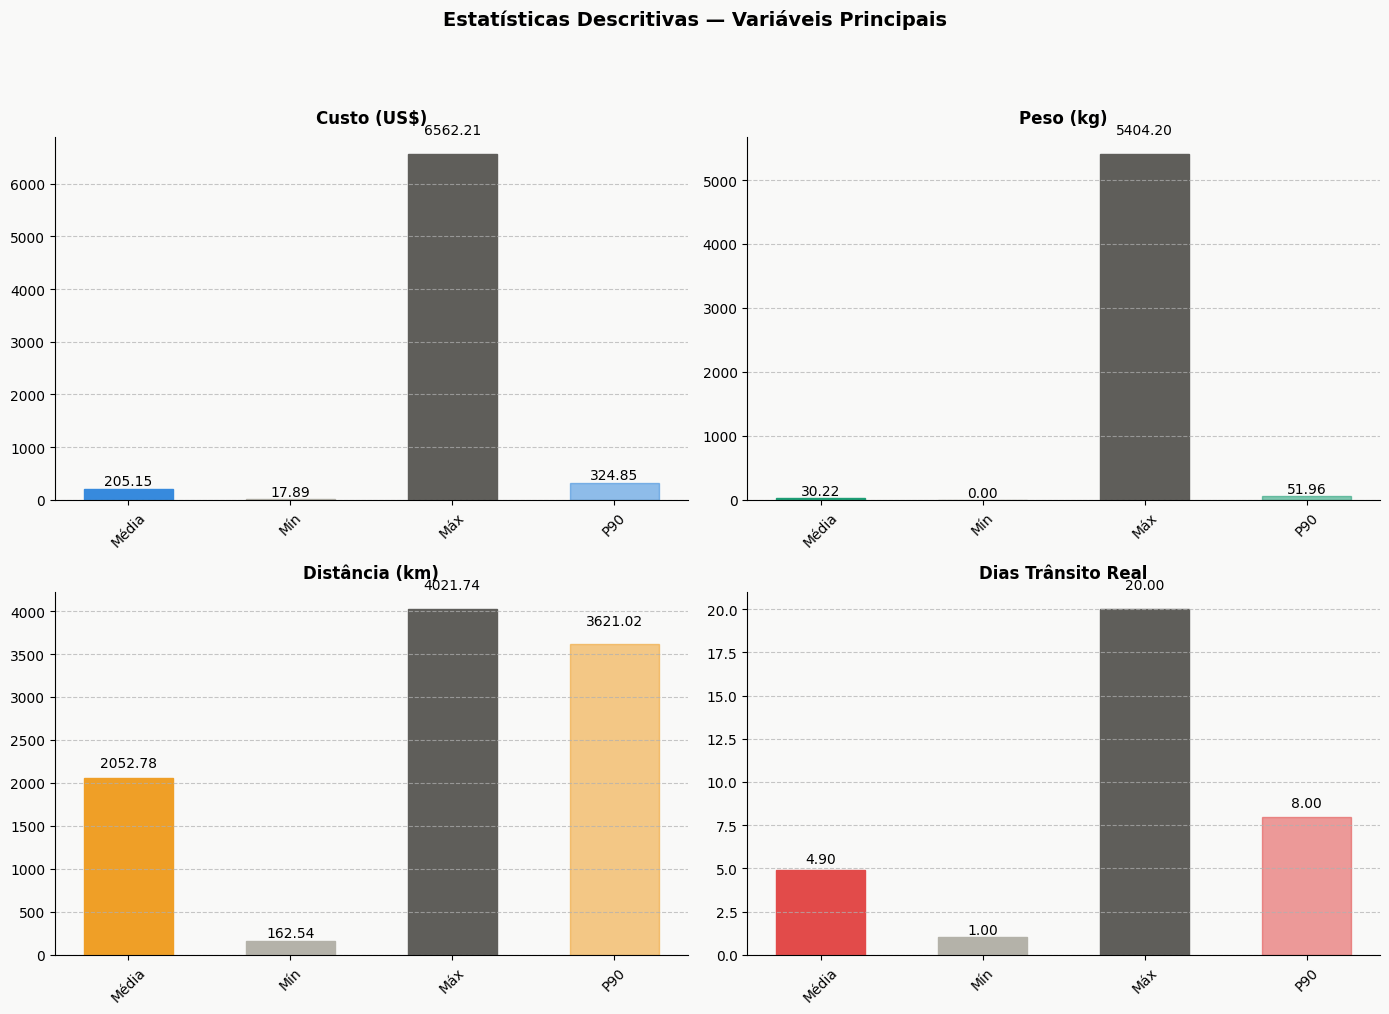

In [ ]:
# Representação gráficas das estatísticas descritivas das variáveis principais
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Estatísticas Descritivas — Variáveis Principais', fontsize=14, fontweight='bold', y=1.01)

variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_real']
titulos   = ['Custo (US$)', 'Peso (kg)', 'Distância (km)', 'Dias Trânsito Real']
cor_barra = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A']

for ax, var, titulo, cor in zip(axes.flat, variaveis, titulos, cor_barra):
    row = estatisticas.loc[var]
    metricas = ['mean', 'min', 'max', 'percentil_90']
    labels   = ['Média', 'Mín', 'Máx', 'P90']
    valores  = [row[m] for m in metricas]

    bars = ax.bar(labels, valores, color=[cor, '#B4B2A9', '#888780', cor + 'aa'],
                  edgecolor='white', width=0.55)

    bars[0].set_color(cor)
    bars[1].set_color('#B4B2A9')
    bars[2].set_color('#5F5E5A')
    bars[3].set_color(cor)
    bars[3].set_alpha(0.55)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (bar.get_height() * 0.05),
                f'{val:.2f}', ha='center', va='bottom')

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_facecolor('#f9f9f8')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('estatisticas_descritivas.png', dpi=150, bbox_inches='tight')
plt.show()

Foram calculadas estatísticas descritivas das principais variáveis da operação, incluindo distância percorrida, peso transportado, custo do envio e tempo de trânsito.

Essa etapa teve como objetivo estabelecer uma visão geral da operação logística antes das análises detalhadas, identificando padrões, dispersões e possíveis valores extremos que poderiam impactar os indicadores de atraso e custo.

<br> **Resultados:**

| Variável           | Média   | Mínimo | Máximo  | Percentil 90 |
|--------------------|---------|--------|---------|--------------|
| custo              | 205.15  | 17.89  | 6562.21 | 324.85       |
| peso_kg            | 30.22   | 0.00   | 5404.20 | 51.96        |
| distancia_km       | 2052.78 | 162.54 | 4021.74 | 3621.02      |
| dias_transito_real | 4.90    | 1.00   | 20.00   | 8.00         |

<br>**Insights identificados:**
- `custo` apresenta elevada variabilidade, com média de 205 e valor máximo maior que 6.500, sugerindo a existência de entregas com características operacionais significativamente diferentes das demais.
- `peso_kg` também apresenta alta variabilidade com média de 30 kg e valor máximo superior a 5.400 kg, indicando a presença de cargas significativamente maiores que o padrão da operação.
- `distancia_km` apresenta grande amplitude, variando entre 162 e 4.022 km, indicando que a operação atende rotas de diferentes perfis logísticos.
- `dias_transito_real` chega a 20 dias, percentil 90 de 8 dias indica que 90% das entregas chegam em até 8 dias

<br>**Insights Princial:**  
Os resultados indicam grande variação entre as entregas analisadas. Enquanto a maior parte das operações apresenta custos, pesos e tempos de trânsito dentro de faixas relativamente concentradas, existem entregas com valores significativamente superiores à média. Dessa forma, serão necessárias análises mais detalhadas para entender como fatores como rota, distância, peso e transportadora influenciam o desempenho da operação.

### 4.3 Análise de evolução das entregas ao longo do tempo

Objetivo:
avaliar a evolução da taxa de atraso e do volume de entregas ao longo do tempo.



In [ ]:
# Agrupamento dos dados por data de entrega

evolucao_por_entrega = (
    df.groupby(df['data_entrega'].dt.to_period('M'))
    .agg(
        total_entregas=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_entregas'] * 100)
)

print(evolucao_por_entrega)

              total_entregas total_atrasados taxa_atraso
data_entrega                                            
2023-01                  136              22   16.176471
2023-02                  128              23    17.96875
2023-03                  168              36   21.428571
2023-04                  152              36   23.684211
2023-05                  170              38   22.352941
2023-06                  156              23    14.74359
2023-07                  167              30   17.964072
2023-08                  178              41   23.033708
2023-09                  169              36   21.301775
2023-10                  163              37   22.699387
2023-11                  166              38   22.891566
2023-12                  161              34   21.118012
2024-01                   38              13   34.210526


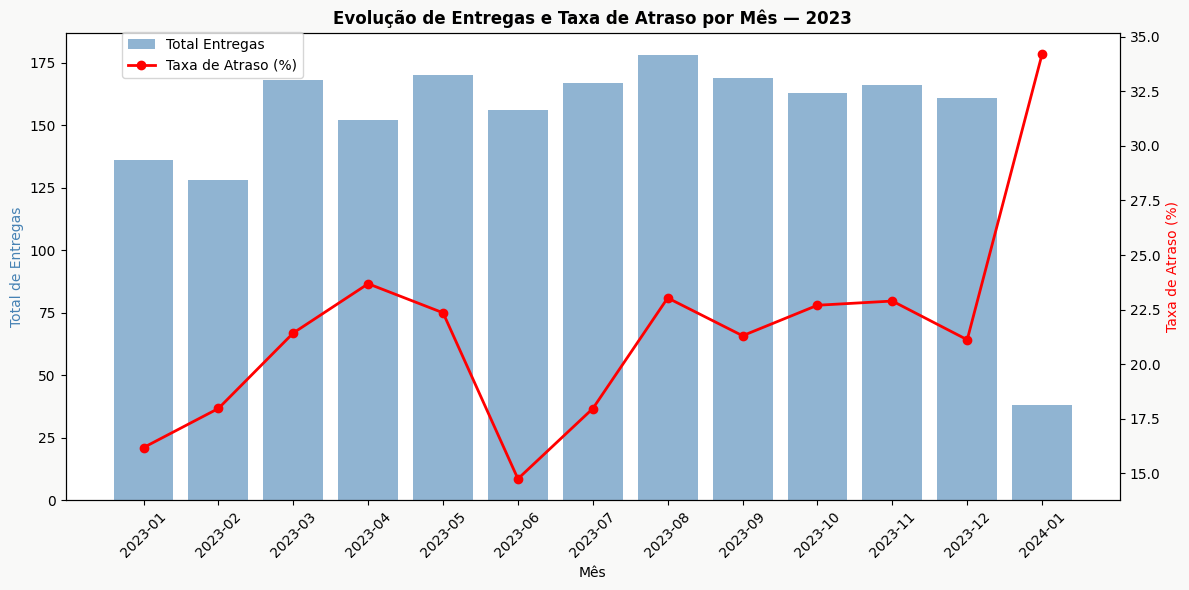

In [ ]:
# Representação gráfica das entregas ao logo do tempo
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

# Eixo esquerdo - total de entregas
ax1.bar(evolucao_por_entrega.index.astype(str),
        evolucao_por_entrega['total_entregas'],
        color='steelblue', alpha=0.6, label='Total Entregas')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Total de Entregas', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Eixo direito - taxa de atraso
ax2 = ax1.twinx()
ax2.plot(evolucao_por_entrega.index.astype(str),
         evolucao_por_entrega['taxa_atraso'],
         color='red', marker='o', linewidth=2, label='Taxa de Atraso (%)')
ax2.set_ylabel('Taxa de Atraso (%)', color='red')

# Titulo e legenda
plt.title('Evolução de Entregas e Taxa de Atraso por Mês — 2023', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

plt.tight_layout()
plt.savefig('evolucao_entregas_taxa.png', dpi=150, bbox_inches='tight')
plt.show()

Agrupamento por mês de entrega para identificar padrões temporais
de volume e taxa de atraso ao longo de 2023.

<br>**Padrões identificados:**
- Janeiro/2024 foi desconsiderado da análise devido ao baixo volume de entregas, o que pode indicar dados incompletos para o período.
- O volume de entregas manteve-se relativamente estável ao longo do período analisado (entre 128 e 178 por mês)
- Junho/2023 apresentou a menor taxa de atraso da série (14.74%)
- Abril/2023 registrou a maior taxa de atraso entre os meses com volume representativo de entregas (23.68%)

<br>**Insight:**   
Apesar da estabilidade no volume de entregas ao longo de 2023, a taxa de atraso apresentou oscilações relevantes entre os meses. Esse comportamento sugere que fatores operacionais além da quantidade de entregas podem estar influenciando o desempenho logístico, reforçando a necessidade de aprofundar a análise por rota, distância e transportadora nas próximas etapas.

### 4.4 - Análise atraso por transportadora

Objetivo:
investigar se existem diferenças significativas de desempenho entre as transportadoras.

In [ ]:
# Agrupamento dos dados por transportadora
df_transportadora = (
    df.groupby('transportadora')
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_envios'])
)

print(df_transportadora)

                  total_envios total_atrasados taxa_atraso
transportadora                                            
AMAZON LOGISTICS           271              67    0.247232
DHL                        280              66    0.235714
FEDEX                      291              62    0.213058
LASERSHIP                  302              62    0.205298
ONTRAC                     297              59    0.198653
UPS                        256              43    0.167969
USPS                       286              48    0.167832


In [ ]:
# Calcula o intervalo de confiança de Wilson Score para a taxa de atraso
lower, upper = proportion_confint(
    count=df_transportadora['total_atrasados'],
    nobs=df_transportadora['total_envios'],
    method='wilson'
)

# Utiliza o limite inferior como score de comparação
df_transportadora['wilson_score'] = lower

print(df_transportadora.sort_values('wilson_score', ascending=False))

                  total_envios total_atrasados taxa_atraso  wilson_score
transportadora                                                          
AMAZON LOGISTICS           271              67    0.247232      0.199641
DHL                        280              66    0.235714      0.189784
FEDEX                      291              62    0.213058      0.169909
LASERSHIP                  302              62    0.205298      0.163580
ONTRAC                     297              59    0.198653      0.157252
USPS                       286              48    0.167832      0.128986
UPS                        256              43    0.167969      0.127159


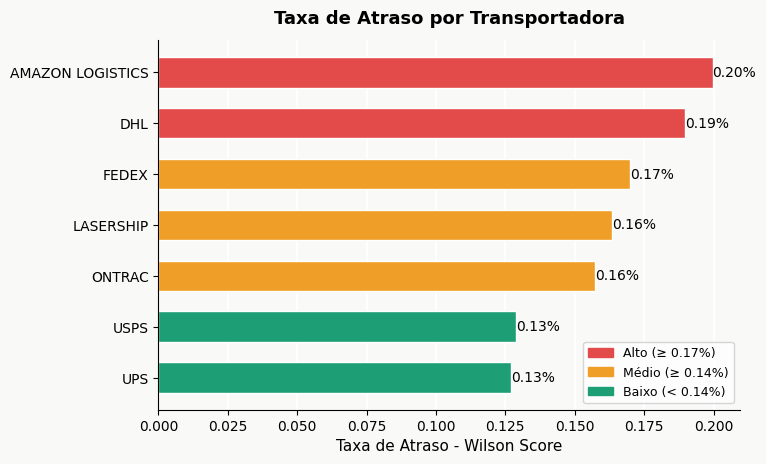

In [ ]:
# Representação gráfica do df_transportadora
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f9f9f8')

df_plot = df_transportadora.sort_values(by='wilson_score',ascending=False)

transportadoras = df_plot.index.tolist()
taxas_wilson = df_plot['wilson_score'].tolist()

cores = ['#E24B4A' if t >= 0.17 else '#EF9F27' if t >= 0.14 else '#1D9E75' for t in taxas_wilson]

bars = ax.barh(transportadoras, taxas_wilson, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso - Wilson Score', fontsize=11)
ax.set_title('Taxa de Atraso por Transportadora', fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas_wilson):
    ax.text(val, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 0.17%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 0.14%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 0.14%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

Agrupamento por `transportadora` para calcular o desempenho de cada transportadorar em relação aos atrasos.


<br>**Métricas calculadas:**
* `total_envios` → total de envios por transportadora
* `total_atrasados` → quantidade de envios classificados como ATRASADO(True)
* `taxa_atraso` → percentual de envios atrasados sobre o total
* `wilson_score` → indicador usado para comparar as transportadoras de forma mais justa, considerando tanto a taxa de atraso quanto a quantidade de envios

<br>**Insights identificados:**

* A Amazon Logistics apresentou a maior taxa de atraso (24,72%), seguida pela DHL (23,57%) e FedEx (21,31%).
* UPS e USPS apresentaram as menores taxas de atraso da amostra, ambas próximas de 17%.
* As demais transportadoras apresentaram resultados intermediários, com taxas de atraso entre 19% e 20%.
* Foi aplicado o método Wilson Score para avaliar a confiabilidade das taxas observadas, considerando simultaneamente a proporção de atrasos e o volume de entregas de cada transportadora.
* O ranking obtido pelo Wilson Score permaneceu praticamente igual ao ranking da taxa de atraso simples.

<br>**Insights Principal:**  
A análise evidencia diferenças consistentes de desempenho entre as transportadoras. Amazon Logistics e DHL apresentaram as maiores taxas de atraso, enquanto UPS e USPS registraram os melhores resultados de pontualidade.

A aplicação do Wilson Score não alterou significativamente o ranking das transportadoras, indicando que as conclusões permanecem estáveis mesmo após o ajuste estatístico. Como os volumes de entrega são semelhantes entre os grupos analisados, as diferenças observadas tendem a refletir comportamentos operacionais reais e não efeitos causados por amostras reduzidas.


### 4.5 - Análise atraso por rota

Objetivo:
investigar se existem diferenças significativas de desempenho entre as rotas.

In [ ]:
# Agrupamento dos dados por rota
df_rota = (
    df.groupby(['rota'])
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios']))
)

print(df_rota)
# A base contém 150 rotas distintas

                              total_envios total_atrasados taxa_atraso
rota                                                                  
Warehouse_ATL - Atlanta                 13               3    0.230769
Warehouse_ATL - Boston                  17               4    0.235294
Warehouse_ATL - Chicago                 15               3         0.2
Warehouse_ATL - Dallas                  16               2       0.125
Warehouse_ATL - Denver                  13               5    0.384615
...                                    ...             ...         ...
Warehouse_SF - New York                 17               4    0.235294
Warehouse_SF - Phoenix                  18               3    0.166667
Warehouse_SF - Portland                 17               5    0.294118
Warehouse_SF - San Francisco            12               1    0.083333
Warehouse_SF - Seattle                  14               2    0.142857

[150 rows x 3 columns]


In [ ]:
# Calcula o intervalo de confiança de Wilson para a taxa de atraso
lower, upper = proportion_confint(
    count=df_rota['total_atrasados'],
    nobs=df_rota['total_envios'],
    method='wilson'
)

# Utiliza o limite inferior como score de comparação
df_rota['wilson_score'] = lower

print('Top 10 rotas com maior indice de atraso (ordenadas por wilson score)\n', df_rota.sort_values('wilson_score', ascending=False).head(10).to_string())
print('\nTop 10 rotas com maior indice de atraso (ordenadas por taxa de atraso)\n', df_rota.sort_values('taxa_atraso', ascending=False).head(10).to_string())

Top 10 rotas com maior indice de atraso (ordenadas por wilson socre)
                                total_envios total_atrasados taxa_atraso  wilson_score
rota                                                                                 
Warehouse_ATL - Detroit                  12               5    0.416667      0.193260
Warehouse_HOU - Portland                 12               5    0.416667      0.193260
Warehouse_SF - Chicago                   12               5    0.416667      0.193260
Warehouse_ATL - Denver                   13               5    0.384615      0.177097
Warehouse_BOS - Houston                  13               5    0.384615      0.177097
Warehouse_NYC - Minneapolis              14               5    0.357143      0.163447
Warehouse_DEN - Miami                    15               5    0.333333      0.151763
Warehouse_MIA - Denver                   16               5      0.3125      0.141646
Warehouse_NYC - San Francisco            12               4    0.33333

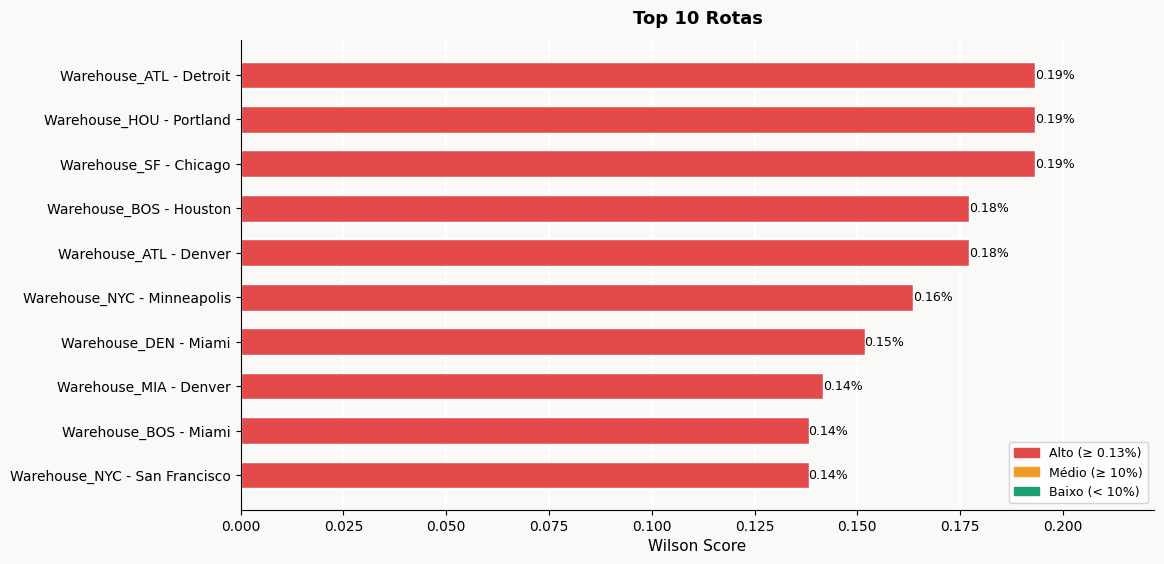

In [ ]:
# Representação gráfica do df_rota
df_rota['wilson_score'] = df_rota['wilson_score'].astype(float)

df_rota_plot = (
    df_rota
    .reset_index()
    .nlargest(10, 'wilson_score')
    .sort_values('wilson_score', ascending=True)
)

rotas = df_rota_plot['rota'].tolist()
taxas_wilson = df_rota_plot['wilson_score'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

cores = [
    '#E24B4A' if t >= 0.13
    else '#EF9F27' if 0.10 <= t < 0.13
    else '#1D9E75'
    for t in taxas_wilson
]

bars = ax.barh(rotas, taxas_wilson, color=cores, edgecolor='white', height=0.6)

ax.set_xlabel('Wilson Score', fontsize=11)
ax.set_title('Top 10 Rotas',
             fontsize=13,
             fontweight='bold',
             pad=12)

ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas_wilson):
    ax.text(
        val,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}%',
        va='center',
        fontsize=9
    )

ax.set_xlim(0, max(taxas_wilson) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 0.13%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 10%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 10%)')

ax.legend(handles=[p_verm, p_lara, p_verd],
          fontsize=9,
          loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

Agrupamento por `rotas` para calcular o desempenho de cada rota em relação aos atrasos.

**Métricas calculadas:**
- `total_envios` → total de envios por rota
- `total_atrasados` → quantidade de envios classificados como ATRASADO(True)
- `taxa_atraso` → percentual de envios atrasados sobre o total
- `wilson_score` → indicador usado para comparar as transportadoras de forma mais justa, considerando tanto a taxa de atraso quanto a quantidade de envios


<br>**Insights identificados:**
- Algumas rotas apresentaram taxas de atraso superiores a 40%, concentrando os piores resultados da operação.
- Foi aplicado o método Wilson Score para avaliar a confiabilidade das taxas observadas, considerando simultaneamente o percentual de atrasos e o volume de entregas de cada rota.
- As rotas Warehouse_ATL - Detroit, Warehouse_HOU - Portland e Warehouse_SF - Chicago apresentaram os maiores índices de atraso após o ajuste pelo Wilson Score.
- Os atrasos não se concentram em uma única rota, indicando diferenças de desempenho ao longo da operação logística.
- Após o ajuste estatístico, algumas rotas com poucos registros perderam relevância no ranking, enquanto rotas com maior volume de entregas mantiveram posições de destaque.

<br>**Insight Principal:**   
A análise mostrou que algumas rotas apresentam mais atrasos que outras, indicando diferenças de desempenho ao longo da operação.

A aplicação do Wilson Score permitiu reduzir o impacto de rotas com poucas entregas, aumentando a confiabilidade dos resultados. Dessa forma, as rotas que permaneceram entre os piores desempenhos após o ajuste representam oportunidades mais consistentes para investigação e melhoria operacional.

<br> **Observação:**  
Rotas com baixo volume de entregas devem ser interpretadas com cautela, pois poucos atrasos adicionais podem provocar grandes variações na taxa observada.

### 4.6 - Análise de custo por km

Objetivo:
investigar o comportamento dos custos logísticos entre as rotas

In [ ]:
# Rotas com maior custo por quilômetro
custo_por_km_rota = (
    df[(df['distancia_km'] > 0) & (df['custo'].notna())] # excluir distancia menor que 0 e nulos em custo
    .groupby(['rota'])
    .apply(lambda x: (x['custo'] / x['distancia_km']).mean()) # media da rota, porque na mesma tem vários envios
    .reset_index(name='media_custo_por_km')
    .sort_values('media_custo_por_km', ascending=False)
)

print(custo_por_km_rota.head(10))

                             rota  media_custo_por_km
88   Warehouse_LA - San Francisco            0.291714
106        Warehouse_NYC - Boston            0.193116
65        Warehouse_HOU - Detroit            0.185988
32        Warehouse_CHI - Chicago            0.171439
7     Warehouse_ATL - Los Angeles            0.160039
35        Warehouse_CHI - Detroit            0.157510
82     Warehouse_LA - Los Angeles            0.140521
96        Warehouse_MIA - Houston            0.137857
122       Warehouse_SEA - Chicago            0.137545
76          Warehouse_LA - Boston            0.136434


/tmp/ipykernel_17574/2526609599.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['custo'] / x['distancia_km']).mean()) # media da rota, porque na mesma tem vários envios


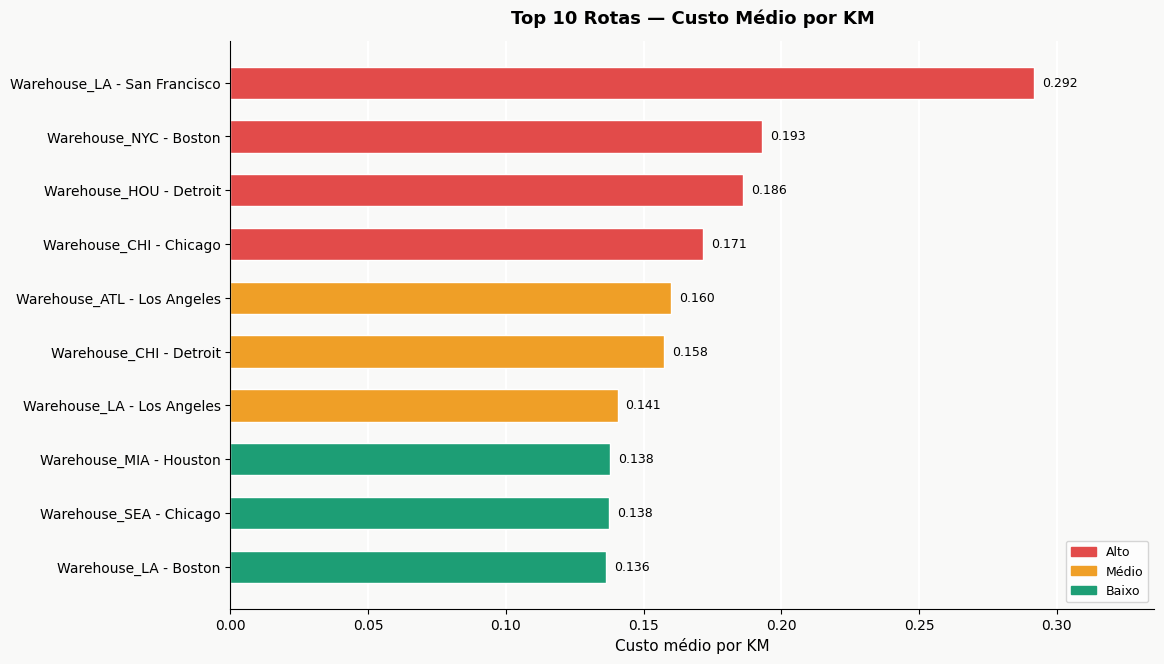

In [ ]:
# Representação gráficas das rotas com maior custo por quilômetro
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f9f8')

custo_plot = custo_por_km_rota.nlargest(10, 'media_custo_por_km').copy()
custo_plot['rota'] = custo_plot['rota']
custo_plot = custo_plot.sort_values('media_custo_por_km', ascending=True)

rotas  = custo_plot['rota'].tolist()
custos = custo_plot['media_custo_por_km'].tolist()

def cor(i, total):
    t = i / (total - 1)
    if t >= 0.66: return '#E24B4A'
    if t >= 0.33: return '#EF9F27'
    return '#1D9E75'

cores = [cor(i, len(custos)) for i in range(len(custos))]

bars = ax.barh(rotas, custos, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Custo médio por KM', fontsize=11)
ax.set_title('Top 10 Rotas — Custo Médio por KM', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, custos):
    ax.text(val + max(custos) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlim(0, max(custos) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('custo_por_km_rotas.png', dpi=150, bbox_inches='tight')
plt.show()



**Top 3 rotas com maior custo por km:**
- Warehouse_LA para San Francisco: 0.29 por km (maior custo - rota curta com custo fixo alto)
- Warehouse_NYC para Boston: 0.19 por km
- Warehouse_HOU para Detroit: 0.18 por km

<br>**Insight Identificado:**

- A rota Warehouse_LA - San Francisco apresentou o maior custo médio por km da operação (0,29), valor significativamente superior às demais rotas analisadas.
- As rotas Warehouse_NYC - Boston e Warehouse_HOU - Detroit completam o grupo das três rotas com maior custo por km.
- Foi observada grande variação no custo por km entre as rotas, indicando diferenças relevantes na eficiência econômica dos trajetos.
- Algumas rotas apresentam custos proporcionalmente mais elevados, o que pode estar relacionado a características específicas da operação que merecem investigação adicional.

<br>**Insight Principal:**   
Os resultados mostram que o custo por km não é uniforme entre as rotas. Algumas apresentam custos significativamente mais elevados, sugerindo a necessidade de uma análise mais detalhada para entender os fatores associados a esse comportamento.

### 4.7 - Análise de custo por peso

Objetivo:
avaliar o custo médio por quilograma entre as rotas, identificando trajetos com maior custo

In [ ]:
# Média de custo por peso - top 10
custo_por_kg = (
    df[(df['peso_kg'] > 0) & (df['custo'].notna())] # tira o único peso zero que tem e exclui os nulos em custo
    .groupby(['rota'])
    .apply(lambda x: (x['custo'] / x['peso_kg']).mean())
    .reset_index(name='media_custo_por_kg')
    .sort_values('media_custo_por_kg', ascending=False)
)

print(custo_por_kg.head(10))

                              rota  media_custo_por_kg
74         Warehouse_HOU - Seattle          115.685876
0          Warehouse_ATL - Atlanta           84.409757
103  Warehouse_MIA - San Francisco           78.505482
98           Warehouse_MIA - Miami           69.709973
21         Warehouse_BOS - Houston           56.620921
65         Warehouse_HOU - Detroit           41.734202
69     Warehouse_HOU - Minneapolis           35.133860
89          Warehouse_LA - Seattle           34.996405
23           Warehouse_BOS - Miami           23.446208
118  Warehouse_NYC - San Francisco           18.837008


/tmp/ipykernel_17574/1966946961.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['custo'] / x['peso_kg']).mean())


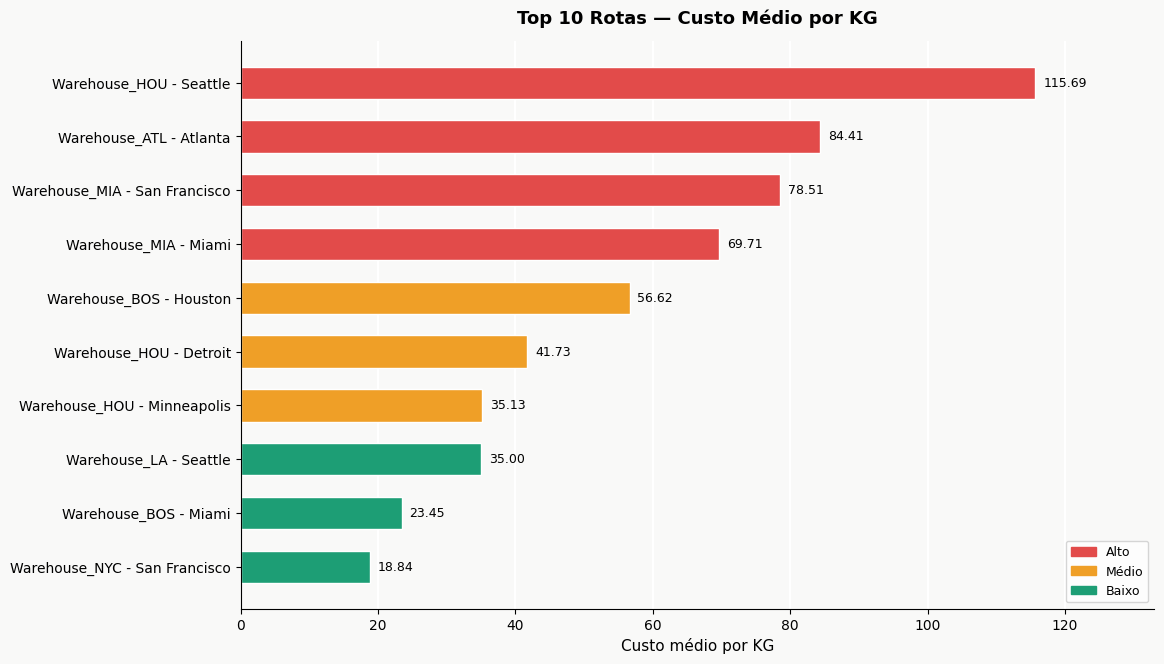

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f9f8')

custo_plot = custo_por_kg.nlargest(10, 'media_custo_por_kg').copy()
custo_plot['rota'] = custo_plot['rota']
custo_plot = custo_plot.sort_values('media_custo_por_kg', ascending=True)

rotas  = custo_plot['rota'].tolist()
custos = custo_plot['media_custo_por_kg'].tolist()

def cor(i, total):
    t = i / (total - 1)
    if t >= 0.66: return '#E24B4A'
    if t >= 0.33: return '#EF9F27'
    return '#1D9E75'

cores = [cor(i, len(custos)) for i in range(len(custos))]

bars = ax.barh(rotas, custos, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Custo médio por KG', fontsize=11)
ax.set_title('Top 10 Rotas — Custo Médio por KG', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, custos):
    ax.text(val + max(custos) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlim(0, max(custos) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('custo_por_kg_rotas.png', dpi=150, bbox_inches='tight')
plt.show()


<br>**Top 3 rotas com maior custo por kg:**
- Warehouse_HOU → Seattle: 115.69/kg (maior custo)
- Warehouse_ATL → Atlanta: 84.41/kg
- Warehouse_MIA → San Francisco: 78.51/kg

<br>**Insight Identificado:**
- A rota Warehouse_HOU → Seattle apresentou o maior custo médio por kg da operação (115,69/kg), destacando-se significativamente das demais rotas.
- As rotas Warehouse_ATL → Atlanta e Warehouse_MIA → San Francisco completam o grupo das três rotas com maior custo por kg.
- Foi observada grande variação no custo por kg entre as rotas analisadas, indicando diferenças relevantes nos custos de transporte.
- Algumas rotas apresentam custos proporcionalmente mais elevados por unidade de carga, sugerindo oportunidades para investigação e otimização operacional.

<br>**Insight Principal:**
A análise identificou diferenças relevantes no custo por kg entre as rotas. Algumas apresentaram custos proporcionalmente mais elevados, sugerindo oportunidades para avaliar possíveis melhorias na eficiência dos custos logísticos.

## 5. Principais Insights

- As reclamações relacionadas à pontualidade possuem fundamento, uma vez que parte significativa das entregas foi classificada como atrasada.
- Foram identificadas diferenças relevantes de desempenho entre transportadoras e rotas.
- Amazon Logistics e DHL apresentaram as maiores taxas de atraso entre as transportadoras analisadas.
- UPS e USPS apresentaram os melhores resultados de pontualidade.
- Algumas rotas concentraram taxas de atraso significativamente superiores às demais.
- O custo por quilômetro e por quilograma apresentou variações relevantes entre as rotas, indicando diferenças nos custos logísticos da operação.

## 6. Recomendações

### 6.1 Melhorias na Base de Dados para Camada Gold

- Criar coluna rota (origem + destino)
- Criar coluna atraso baseada na regra de negócio definida.
- Criar tabela agregada de indicadores por transportadora, contendo quantidade de envios, quantidade de atrasos, taxa de atraso e Wilson Score.
- Criar tabela agregada de indicadores por rota, contendo quantidade de envios, quantidade de atrasos, taxa de atraso e Wilson Score.


### 6.2 Recomendações para Dashboard
- Exibir KPIs de entregas, atrasos, taxa de atraso e custo médio.
- Criar ranking de transportadoras por taxa de atraso.
- Criar ranking de rotas por taxa de atraso.
- Exibir análises de custo por quilômetro e custo por quilograma.
- Adicionar filtros por período, rota e transportadora.
- Incluir o Wilson Score como indicador complementar para avaliação das taxas de atraso.

### 6.3 Recomendações de Negócio

- Investigar as rotas com maiores taxas de atraso.
- Avaliar o desempenho das transportadoras com piores indicadores de pontualidade.
- Analisar as rotas com maior custo por quilômetro e por quilograma.
- Buscar oportunidades de redução de custos sem comprometer o nível de serviço.
- Implementar o acompanhamento contínuo dos principais indicadores logísticos.

## 7. Criar tabelas da camada GOLD



### 7.1 Validacão da camada **GOLD**

In [ ]:
gold_entregas = df.copy()

print(gold_entregas.shape)
print(gold_entregas.columns.tolist())

### 7.2 Carga da tabela **gold_entregas**

In [ ]:
from sqlalchemy import text

with engine.begin() as conn:
    conn.execute(
        text("TRUNCATE TABLE gold.gold_entregas")
    )

print("Tabela esvaziada")

In [ ]:
gold_entregas.to_sql(
    name='gold_entregas',
    con=engine,
    schema='gold',
    if_exists='append',
    index=False
)

print("Dados carregados com sucesso")

In [ ]:
teste = pd.read_sql(
    """
    SELECT COUNT(*) AS total
    FROM gold.gold_entregas
    """,
    engine
)

print(teste)

### 7.3 Carga da tabela **gold_transportadora**

In [ ]:
gold_transportadora = df_transportadora.reset_index()

gold_transportadora.to_sql(
    name='gold_transportadora',
    con=engine,
    schema='gold',
    if_exists='replace',
    index=False
)

print("Dados carregados com sucesso")

In [ ]:
teste1 = pd.read_sql(
    "SELECT COUNT(*) as total FROM gold.gold_transportadora",
    engine
)

print(teste1)

### 7.4 Carga da tabela **gold_rota**

In [ ]:
gold_rota = df_rota.reset_index()

gold_rota.to_sql(
    name='gold_rota',
    con=engine,
    schema='gold',
    if_exists='replace',
    index=False
)

print("Dados carregados com sucesso")

In [ ]:
teste2 = pd.read_sql(
    "SELECT COUNT(*) as total FROM gold.gold_rota",
    engine
)

print(teste2)

### 7.5 Validação dos objetos da camada gold

In [ ]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'gold'
ORDER BY table_name
""", engine)